# 06: Hybrid Evaluation

Phase 2. Runs the `hybrid` configuration and compares against the three baseline configs from notebook 03. Loads `results/baseline_ablation.csv`. Run notebook 03 first.

Produces `results/hybrid_ablation.csv`, `results/full_comparison.csv`, and comparison bar charts.

## Cell group 1: Imports and constants

In [1]:
import json
import math
import sys
from pathlib import Path
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['figure.dpi'] = 100

SCRIPTS_DIR = Path('scripts').resolve()
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

from retriever import load_retrievers, hybrid_retrieve

DATA_DIR    = Path('data')
CHROMA_DIR  = DATA_DIR / 'chroma_db'
RESULTS_DIR = Path('results')
FIGURES_DIR = Path('figures')
RESULTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

EVAL_K     = [1, 3, 5, 10]
RRF_K      = 60
GRAPH_HOPS = 2
TOP_K      = 10

ALL_CONFIGS = {
    'dense_only':   'Dense only',
    'sparse_only':  'Sparse only',
    'dense_sparse': 'Dense + Sparse',
    'hybrid':       'Hybrid (+ Graph)',
}

print(f'EVAL_K: {EVAL_K}')
print(f'GRAPH_HOPS: {GRAPH_HOPS}')

EVAL_K: [1, 3, 5, 10]
GRAPH_HOPS: 2


In [2]:
from log_setup import setup_logging

logger = setup_logging("06_evaluation_hybrid")

00:59:37  INFO      === Notebook 06_evaluation_hybrid started — log: 2026-07-01_00-59-37_06_evaluation_hybrid.log ===


## Cell group 2: Load baseline results

In [3]:
BASELINE_CSV = RESULTS_DIR / 'baseline_ablation.csv'
if not BASELINE_CSV.exists():
    raise FileNotFoundError(
        f'{BASELINE_CSV} not found: run notebook 03 first to generate baseline results.'
    )
df_baseline = pd.read_csv(BASELINE_CSV)
logger.info('Loaded baseline results: %d rows from %s', len(df_baseline), BASELINE_CSV)
print(f'Loaded {len(df_baseline)} baseline rows from {BASELINE_CSV}')
print(f'Configs present: {df_baseline["config"].unique().tolist()}')

00:59:37  INFO      Loaded baseline results: 15 rows from results\baseline_ablation.csv
Loaded 15 baseline rows from results\baseline_ablation.csv
Configs present: ['dense_only', 'sparse_only', 'dense_sparse']


## Cell group 3: Load full retrievers (with graph)

In [4]:
import time

t0 = time.time()
vectorstore, bm25, clauses, G = load_retrievers(DATA_DIR, CHROMA_DIR)
clause_lookup = {c['clause_id']: c for c in clauses}
logger.info('Full retrievers loaded: %d clauses  (%.1fs)', len(clauses), time.time() - t0)
print(f'Loaded {len(clauses)} clauses  ({time.time()-t0:.1f}s)')
print(f'Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges')

00:59:37  INFO      Loading all retrievers (dense+sparse+graph) from data
00:59:37  INFO      Loading dense+sparse retrievers from data
00:59:45  INFO      HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
00:59:45  INFO      HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/1110a243fdf4706b3f48f1d95db1a4f5529b4d41/modules.json "HTTP/1.1 200 OK"
00:59:45  INFO      HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/config_sentence_transformers.json "HTTP/1.1 307 Temporary Redirect"
00:59:45  INFO      HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/1110a243fdf4706b3f48f1d95db1a4f5529b4d41/config_sentence_transformers.json "HTTP/1.1 200 OK"
00:59:45  INFO      Loading SentenceTransformer model from sentence-transformers/all-MiniLM-L6-v2.
00:59

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

00:59:46  INFO      HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
00:59:46  INFO      HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/preprocessor_config.json "HTTP/1.1 404 Not Found"
00:59:46  INFO      HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/video_preprocessor_config.json "HTTP/1.1 404 Not Found"
00:59:46  INFO      HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/preprocessor_config.json "HTTP/1.1 404 Not Found"
00:59:47  INFO      HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
00:59:47  INFO      HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/1110a243fdf4706b3f48f1d95db1a4f5529b4d41/toke

## Cell group 4: Load test set

Must use the same test set as notebook 03 for a valid comparison.

In [5]:
TEST_SET_PATH = DATA_DIR / 'test_set.jsonl'

if TEST_SET_PATH.exists():
    test_set = [
        json.loads(line)
        for line in TEST_SET_PATH.read_text(encoding='utf-8').splitlines()
        if line.strip()
    ]
    logger.info('Loaded %d test queries', len(test_set))
    print(f'Loaded {len(test_set)} test queries')
else:
    test_set = [
        {'query': 'customer due diligence requirements',                 'gold_ids': ['mlr_2017_reg_28'], 'query_type': 'exact_anchor'},
        {'query': 'concealment of criminal property',                   'gold_ids': ['poca_2002_s327'],  'query_type': 'exact_anchor'},
        {'query': 'politically exposed persons enhanced due diligence', 'gold_ids': ['mlr_2017_reg_35'], 'query_type': 'cross_reference'},
        {'query': 'suspicious activity report obligation',               'gold_ids': ['poca_2002_s330'],  'query_type': 'exact_anchor'},
        {'query': 'beneficial owner definition',                         'gold_ids': ['mlr_2017_reg_6'],  'query_type': 'exact_anchor'},
    ]
    logger.warning('test_set.jsonl not found: using placeholder')
    print(f'Using placeholder test set ({len(test_set)} queries).')

00:59:48  INFO      Loaded 50 test queries
Loaded 50 test queries


## Cell group 5: IR metric functions

Same implementation as notebook 03, duplicated here so this notebook is self-contained.

In [6]:
def precision_at_k(retrieved_ids, gold_ids, k):
    return sum(1 for cid in retrieved_ids[:k] if cid in gold_ids) / k if k else 0.0

def recall_at_k(retrieved_ids, gold_ids, k):
    if not gold_ids: return 0.0
    return sum(1 for cid in retrieved_ids[:k] if cid in gold_ids) / len(gold_ids)

def reciprocal_rank(retrieved_ids, gold_ids):
    for i, cid in enumerate(retrieved_ids):
        if cid in gold_ids: return 1.0 / (i + 1)
    return 0.0

def dcg(retrieved_ids, gold_ids, k):
    return sum(1.0 / __import__('math').log2(i + 2) for i, cid in enumerate(retrieved_ids[:k]) if cid in gold_ids)

def ndcg_at_k(retrieved_ids, gold_ids, k):
    ideal = dcg(gold_ids, gold_ids, k)
    return 0.0 if ideal == 0 else dcg(retrieved_ids, gold_ids, k) / ideal

def evaluate_retrieval(retrieved_ids, gold_ids):
    result = {'mrr': reciprocal_rank(retrieved_ids, gold_ids)}
    for k in EVAL_K:
        result[f'p@{k}']    = precision_at_k(retrieved_ids, gold_ids, k)
        result[f'r@{k}']    = recall_at_k(retrieved_ids, gold_ids, k)
        result[f'ndcg@{k}'] = ndcg_at_k(retrieved_ids, gold_ids, k)
    return result

print('IR metrics ready.')

IR metrics ready.


## Cell group 6: Hybrid retrieval ablation

Runs the `hybrid` configuration over all test queries. Saves `results/hybrid_ablation.csv` and merges with baseline to produce `results/full_comparison.csv`.

In [7]:
rows = []
for item in test_set:
    query    = item['query']
    gold_ids = item['gold_ids']
    qtype    = item.get('query_type', 'unknown')
    retrieved = hybrid_retrieve(
        query, vectorstore, bm25, clauses, G,
        k=max(EVAL_K), graph_hops=GRAPH_HOPS, rrf_k=RRF_K,
    )
    retrieved_ids = [r['clause_id'] for r in retrieved]
    metrics = evaluate_retrieval(retrieved_ids, gold_ids)
    rows.append({'query': query[:50], 'query_type': qtype, 'config': 'hybrid', **metrics})
    logger.debug('hybrid  query=%r  mrr=%.4f', query[:40], metrics['mrr'])

df_hybrid = pd.DataFrame(rows)
df_hybrid.to_csv(RESULTS_DIR / 'hybrid_ablation.csv', index=False)
logger.info('Saved hybrid_ablation.csv  (%d rows)', len(df_hybrid))
print(f'Saved {len(df_hybrid)} rows to results/hybrid_ablation.csv')

df_full = pd.concat([df_baseline, df_hybrid], ignore_index=True)
df_full.to_csv(RESULTS_DIR / 'full_comparison.csv', index=False)
logger.info('Saved full_comparison.csv  (%d rows)', len(df_full))
print(f'Saved {len(df_full)} rows to results/full_comparison.csv')

hybrid_summary = df_hybrid[['mrr', 'p@5', 'r@10', 'ndcg@5']].mean().round(4)
print(f'\nHybrid, mean over test set:')
print(hybrid_summary.to_string())

00:59:48  INFO      hybrid_retrieve: query='Under MLR 2017 regulation 4, at what point is an estate agen'  graph_expanded=11  top-1=mlr_2017_reg_4
00:59:48  INFO      hybrid_retrieve: query='What ownership or voting rights threshold must an individual'  graph_expanded=4  top-1=mlr_2017_reg_5
00:59:49  INFO      hybrid_retrieve: query='Under MLR 2017 regulation 6, which categories of persons are'  graph_expanded=4  top-1=jmlsg_1_5.3.260
00:59:49  INFO      hybrid_retrieve: query="At what cash payment level does a trader become a 'high valu"  graph_expanded=1  top-1=mlr_2017_reg_14
00:59:49  INFO      hybrid_retrieve: query='Under MLR 2017 regulation 27, in what circumstances is a rel'  graph_expanded=64  top-1=mlr_2017_reg_39
00:59:49  INFO      hybrid_retrieve: query='What three obligations does MLR 2017 regulation 28(2) impose'  graph_expanded=64  top-1=mlr_2017_sch6_para7
00:59:49  INFO      hybrid_retrieve: query='Under MLR 2017 regulation 30, when must verification of a cu'  graph_

## Cell group 7: Full comparison

Prints all 4 configurations side by side and saves `figures/full_comparison.png`.

Full comparison — all configs
Dense only:
  MRR=0.2000  P@5=0.0400  R@10=0.2000  NDCG@5=0.2000
00:59:51  INFO      RESULT  config=dense_only            MRR=0.2000  P@5=0.0400  R@10=0.2000  NDCG@5=0.2000
Sparse only:
  MRR=0.0667  P@5=0.0400  R@10=0.2000  NDCG@5=0.1000
00:59:51  INFO      RESULT  config=sparse_only           MRR=0.0667  P@5=0.0400  R@10=0.2000  NDCG@5=0.1000
Dense + Sparse:
  MRR=0.2000  P@5=0.0400  R@10=0.2000  NDCG@5=0.2000
00:59:51  INFO      RESULT  config=dense_sparse          MRR=0.2000  P@5=0.0400  R@10=0.2000  NDCG@5=0.2000
Hybrid (+ Graph):
  MRR=0.5032  P@5=0.1520  R@10=0.6683  NDCG@5=0.4694
00:59:51  INFO      RESULT  config=hybrid                MRR=0.5032  P@5=0.1520  R@10=0.6683  NDCG@5=0.4694

Per-query-type breakdown (hybrid config):
                    mrr    p@5  ndcg@5
query_type                            
cross_reference  0.3880  0.160  0.3079
exact_anchor     0.6183  0.144  0.6309

00:59:52  INFO      Graph gain over dense_sparse: MRR +151.6%  (0.2

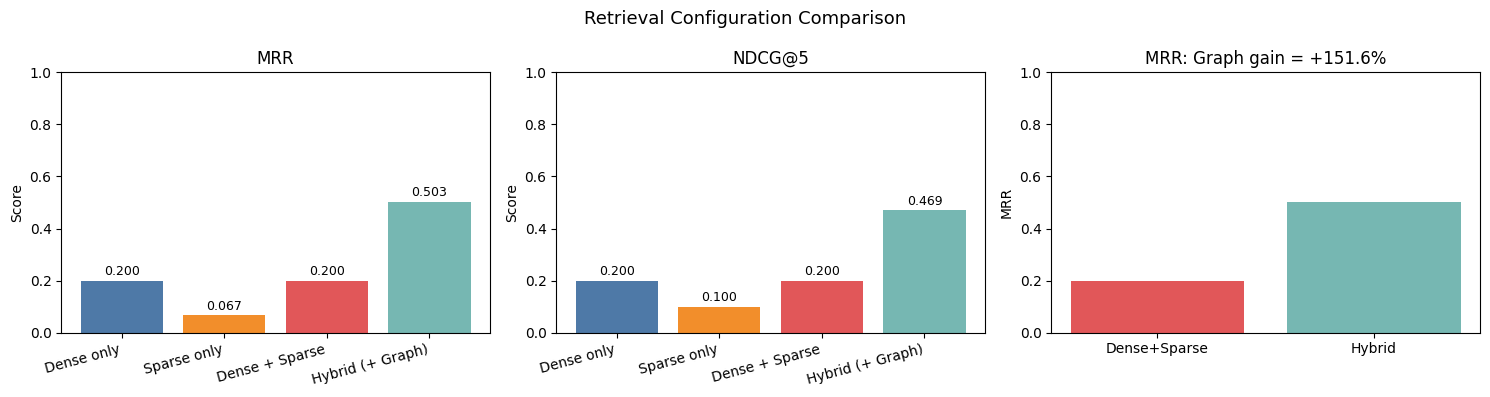

00:59:53  INFO      Plot saved: figures/full_comparison.png
Plot saved to figures/full_comparison.png


In [8]:
print('Full comparison: all configs')
print('=' * 70)
for config, label in ALL_CONFIGS.items():
    subset = df_full[df_full['config'] == config]
    if subset.empty:
        print(f'{label}: no data')
        continue
    mrr = subset['mrr'].mean()
    p5  = subset['p@5'].mean()
    r10 = subset['r@10'].mean()
    n5  = subset['ndcg@5'].mean()
    print(f'{label}:')
    print(f'  MRR={mrr:.4f}  P@5={p5:.4f}  R@10={r10:.4f}  NDCG@5={n5:.4f}')
    logger.info('RESULT  config=%-20s  MRR=%.4f  P@5=%.4f  R@10=%.4f  NDCG@5=%.4f', config, mrr, p5, r10, n5)

print()
if 'query_type' in df_full.columns and df_full['query_type'].nunique() > 1:
    print('Per-query-type breakdown (hybrid config):')
    hyb_df = df_full[df_full['config'] == 'hybrid']
    by_type = hyb_df.groupby('query_type')[['mrr', 'p@5', 'ndcg@5']].mean().round(4)
    print(by_type.to_string())
    print()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric in zip(axes[:2], ['mrr', 'ndcg@5']):
    values = df_full.groupby('config')[metric].mean().reindex(ALL_CONFIGS.keys())
    labels = list(ALL_CONFIGS.values())
    colors = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2']
    bars = ax.bar(range(len(values)), values.values, color=colors)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=15, ha='right')
    ax.set_title(metric.upper())
    ax.set_ylim(0, 1)
    ax.set_ylabel('Score')
    for bar, val in zip(bars, values.values):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.01, f'{val:.3f}',
            ha='center', va='bottom', fontsize=9)

ax = axes[2]
baseline_mrr = df_full[df_full['config'] == 'dense_sparse']['mrr'].mean()
hybrid_mrr   = df_full[df_full['config'] == 'hybrid']['mrr'].mean()
gain_pct     = (hybrid_mrr - baseline_mrr) / max(baseline_mrr, 1e-9) * 100
ax.bar(['Dense+Sparse', 'Hybrid'], [baseline_mrr, hybrid_mrr], color=['#e15759', '#76b7b2'])
ax.set_title(f'MRR: Graph gain = +{gain_pct:.1f}%')
ax.set_ylim(0, 1)
ax.set_ylabel('MRR')
logger.info('Graph gain over dense_sparse: MRR +%.1f%%  (%.4f -> %.4f)', gain_pct, baseline_mrr, hybrid_mrr)

plt.suptitle('Retrieval Configuration Comparison', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'full_comparison.png', bbox_inches='tight')
plt.show()
logger.info('Plot saved: figures/full_comparison.png')
print('Plot saved to figures/full_comparison.png')